# Torre Dinâmica — Demonstração dos Algoritmos

Comparação entre **A\*** e **Busca Gulosa** com **Heurística Forte** (Euclidiana) e **Heurística Fraca** (Manhattan/10) em um tabuleiro 8×8 com terrenos de custo variável.

In [1]:
# Instala dependências se necessário
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib', 'numpy', '--quiet'])

0

In [2]:
import random
import math
import time
import heapq
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from IPython.display import display

# Reprodutibilidade
SEED = 42
random.seed(SEED)

## 1. Tabuleiro

In [ ]:
TAM = 8

CUSTOS = {
    'estrada':  1,
    'neve':     2,
    'terra':    3,
    'areia':    4,
    'lama':     5,
    'floresta': 7,
    'barreira': float('inf'),
}

COR = {
    'estrada':  0,
    'neve':     1,
    'terra':    2,
    'areia':    3,
    'lama':     4,
    'floresta': 5,
    'barreira': 6,
}

def criar_caminho(origem, destino):
    caminho = []
    i, j = origem
    while i != destino[0]:
        caminho.append((i, j))
        i += 1 if i < destino[0] else -1
    while j != destino[1]:
        caminho.append((i, j))
        j += 1 if j < destino[1] else -1
    caminho.append(destino)
    return caminho

def gerar_tabuleiro():
    """Gera tabuleiro 8x8 com origem e destino separados por pelo menos 4 casas (Manhattan)."""
    origem = (random.randint(0, 7), random.randint(0, 7))
    while True:
        destino = (random.randint(0, 7), random.randint(0, 7))
        if abs(origem[0]-destino[0]) + abs(origem[1]-destino[1]) >= 4:
            break

    grade = {}
    for i in range(TAM):
        for j in range(TAM):
            if (i, j) == origem or (i, j) == destino:
                tipo = 'estrada'
            else:
                r = random.random()
                if   r < 0.15: tipo = 'barreira'
                elif r < 0.30: tipo = 'floresta'
                elif r < 0.45: tipo = 'lama'
                elif r < 0.60: tipo = 'areia'
                elif r < 0.75: tipo = 'terra'
                elif r < 0.88: tipo = 'neve'
                else:          tipo = 'estrada'
            grade[(i, j)] = {'tipo': tipo, 'custo': CUSTOS[tipo]}

    for pos in criar_caminho(origem, destino):
        grade[pos] = {'tipo': 'estrada', 'custo': 1}

    return grade, origem, destino

def grade_para_matriz(grade):
    m = np.zeros((TAM, TAM), dtype=int)
    for (i, j), cel in grade.items():
        m[i][j] = COR[cel['tipo']]
    return m

## 2. Heurísticas

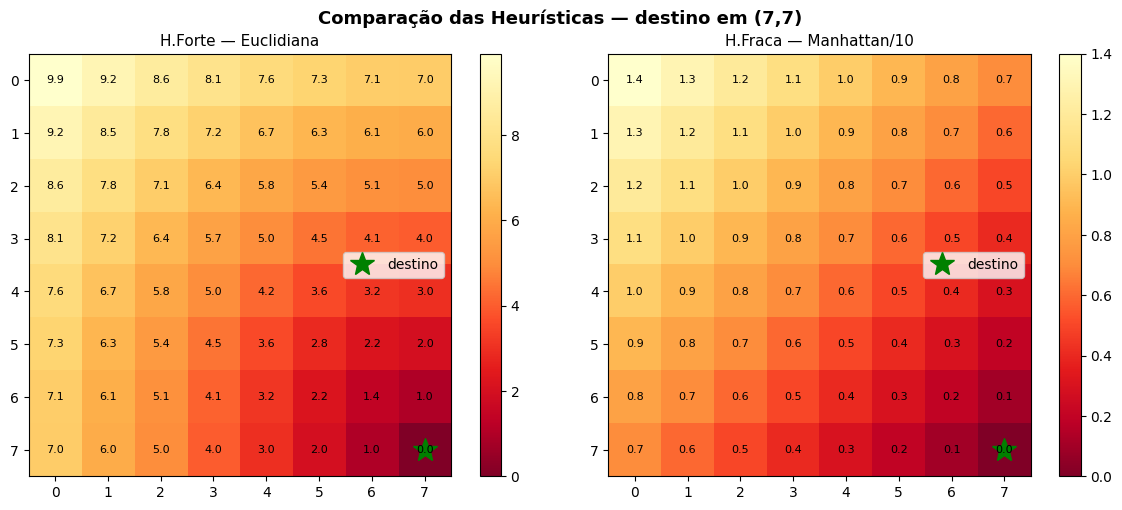

In [5]:
def h_forte(pos, destino):
    """Heurística Forte: Distância Euclidiana."""
    return math.sqrt((destino[0]-pos[0])**2 + (destino[1]-pos[1])**2)

def h_fraca(pos, destino):
    """Heurística Fraca: Manhattan / 10 (subestima drasticamente)."""
    return (abs(destino[0]-pos[0]) + abs(destino[1]-pos[1])) / 10

# Visualização comparativa das heurísticas a partir do canto (0,0)
destino_demo = (7, 7)
vals_forte = np.zeros((TAM, TAM))
vals_fraca = np.zeros((TAM, TAM))
for i in range(TAM):
    for j in range(TAM):
        vals_forte[i][j] = h_forte((i,j), destino_demo)
        vals_fraca[i][j] = h_fraca((i,j), destino_demo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Comparação das Heurísticas — destino em (7,7)', fontsize=13, fontweight='bold')

for ax, vals, titulo in zip(axes, [vals_forte, vals_fraca], ['H.Forte — Euclidiana', 'H.Fraca — Manhattan/10']):
    im = ax.imshow(vals, cmap='YlOrRd_r', vmin=0)
    for i in range(TAM):
        for j in range(TAM):
            ax.text(j, i, f'{vals[i][j]:.1f}', ha='center', va='center', fontsize=8)
    ax.plot(7, 7, 'g*', markersize=18, label='destino')
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(range(TAM))
    ax.set_yticks(range(TAM))
    ax.legend()
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 3. Algoritmos de Busca

In [6]:
DIRECOES = [(-1,0),(1,0),(0,-1),(0,1)]

def reconstruir_caminho(anterior, origem, destino):
    caminho = []
    atual = destino
    while atual and atual != origem:
        caminho.append(atual)
        atual = anterior.get(atual)
    if atual == origem:
        caminho.append(origem)
        return list(reversed(caminho))
    return None

def a_estrela(grade, origem, destino, heuristica):
    visitados = set()
    g = {origem: 0}
    anterior = {}
    ordem_expansao = []
    # (f, contador, pos) — contador desempata para evitar comparar tuplas incompatíveis
    fila = [(heuristica(origem, destino), 0, origem)]
    contador = 1

    while fila:
        _, _, atual = heapq.heappop(fila)
        if atual in visitados:
            continue
        visitados.add(atual)
        ordem_expansao.append(atual)

        if atual == destino:
            break

        for di, dj in DIRECOES:
            viz = (atual[0]+di, atual[1]+dj)
            if not (0 <= viz[0] < TAM and 0 <= viz[1] < TAM):
                continue
            if grade[viz]['custo'] == float('inf') or viz in visitados:
                continue
            novo_g = g[atual] + grade[viz]['custo']
            if novo_g < g.get(viz, float('inf')):
                g[viz] = novo_g
                anterior[viz] = atual
                f = novo_g + heuristica(viz, destino)
                heapq.heappush(fila, (f, contador, viz))
                contador += 1

    caminho = reconstruir_caminho(anterior, origem, destino)
    custo = g.get(destino)
    return caminho, len(ordem_expansao), custo, ordem_expansao

def guloso(grade, origem, destino, heuristica):
    visitados = set()
    anterior = {}
    ordem_expansao = []
    fila = [(heuristica(origem, destino), 0, origem)]
    contador = 1

    while fila:
        _, _, atual = heapq.heappop(fila)
        if atual in visitados:
            continue
        visitados.add(atual)
        ordem_expansao.append(atual)

        if atual == destino:
            break

        for di, dj in DIRECOES:
            viz = (atual[0]+di, atual[1]+dj)
            if not (0 <= viz[0] < TAM and 0 <= viz[1] < TAM):
                continue
            if grade[viz]['custo'] == float('inf') or viz in visitados:
                continue
            anterior[viz] = atual
            heapq.heappush(fila, (heuristica(viz, destino), contador, viz))
            contador += 1

    caminho = reconstruir_caminho(anterior, origem, destino)
    custo = None
    if caminho:
        custo = sum(grade[p]['custo'] for p in caminho[1:])
    return caminho, len(ordem_expansao), custo, ordem_expansao

## 4. Visualização de uma Busca

In [ ]:
# estrada, neve, terra, areia, lama, floresta, barreira
PALETA_TERRENO = ListedColormap([
    '#d4e8a2', '#bfdbfe', '#c8a46e', '#e8d5a0', '#7ba3b0', '#4a7c59', '#4a4a4a'
])
LEGENDA_TERRENOS = [
    mpatches.Patch(color='#d4e8a2', label='Estrada (1)'),
    mpatches.Patch(color='#bfdbfe', label='Neve (2)'),
    mpatches.Patch(color='#c8a46e', label='Terra (3)'),
    mpatches.Patch(color='#e8d5a0', label='Areia (4)'),
    mpatches.Patch(color='#7ba3b0', label='Lama (5)'),
    mpatches.Patch(color='#4a7c59', label='Floresta (7)'),
    mpatches.Patch(color='#4a4a4a', label='Barreira (∞)'),
    mpatches.Patch(color='#555555', label='Nó expandido'),
    mpatches.Patch(color='#2ecc71', label='Caminho ótimo'),
    mpatches.Patch(color='#e74c3c', label='Caminho sub-ótimo'),
]

def plotar_busca(grade, origem, destino, caminho, expansao, titulo, custo_otimo=None, ax=None):
    proprio_ax = ax is None
    if proprio_ax:
        fig, ax = plt.subplots(figsize=(6, 6))

    matriz = grade_para_matriz(grade)
    ax.imshow(matriz, cmap=PALETA_TERRENO, vmin=0, vmax=6, alpha=0.85)

    caminho_set = set(caminho) if caminho else set()
    for pos in expansao:
        if pos not in caminho_set and pos != origem and pos != destino:
            ax.add_patch(plt.Circle((pos[1], pos[0]), 0.3, color='#555555', alpha=0.5))

    otimo = custo_otimo is None or (caminho and sum(grade[p]['custo'] for p in caminho[1:]) <= custo_otimo + 0.001)
    cor_caminho = '#2ecc71' if otimo else '#e74c3c'
    if caminho and len(caminho) > 1:
        xs = [p[1] for p in caminho]
        ys = [p[0] for p in caminho]
        ax.plot(xs, ys, '-', color=cor_caminho, linewidth=3, zorder=5)
        for pos in caminho[1:-1]:
            ax.add_patch(plt.Circle((pos[1], pos[0]), 0.25, color=cor_caminho, zorder=6))

    for i in range(TAM):
        for j in range(TAM):
            c = grade[(i,j)]['custo']
            txt = '∞' if c == float('inf') else str(c)
            ax.text(j, i, txt, ha='center', va='center', fontsize=7, color='#111', alpha=0.75)

    ax.plot(origem[1], origem[0], 'bs', markersize=14, zorder=7)
    ax.plot(destino[1], destino[0], 'r*', markersize=14, zorder=7)

    custo_real = sum(grade[p]['custo'] for p in caminho[1:]) if caminho else None
    info = f'Nós: {len(expansao)} | Custo: {custo_real}'
    if custo_otimo is not None and custo_real is not None and custo_real > custo_otimo:
        info += f' (+{custo_real - custo_otimo} acima do ótimo)'
    ax.set_title(f'{titulo}\n{info}', fontsize=9)
    ax.set_xticks(range(TAM))
    ax.set_yticks(range(TAM))
    ax.set_xticklabels(['A','B','C','D','E','F','G','H'], fontsize=8)
    ax.set_yticklabels([str(8-i) for i in range(TAM)], fontsize=8)
    ax.grid(True, color='white', linewidth=0.5)

    if proprio_ax:
        ax.legend(handles=LEGENDA_TERRENOS, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
        plt.tight_layout()
        plt.show()

## 5. Comparação das 4 Combinações — Tabuleiro Único

In [ ]:
random.seed(SEED)
grade, origem, destino = gerar_tabuleiro()

combinacoes = [
    ('A* + H.Forte',     a_estrela, h_forte),
    ('A* + H.Fraca',     a_estrela, h_fraca),
    ('Guloso + H.Forte', guloso,    h_forte),
    ('Guloso + H.Fraca', guloso,    h_fraca),
]

_, _, custo_otimo, _ = a_estrela(grade, origem, destino, h_forte)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(
    f'Comparação: Origem {origem} → Destino {destino}  |  Custo ótimo = {custo_otimo}',
    fontsize=13, fontweight='bold'
)

for ax, (nome, algo, h) in zip(axes.flat, combinacoes):
    caminho, nos, custo, expansao = algo(grade, origem, destino, h)
    plotar_busca(grade, origem, destino, caminho, expansao, nome, custo_otimo, ax=ax)

fig.legend(
    handles=LEGENDA_TERRENOS + [
        plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='blue', markersize=10, label='Origem'),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='red',  markersize=12, label='Destino'),
    ],
    loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.04)
)
plt.tight_layout()
plt.show()

## 6. Análise Estatística — 20 Rodadas

In [41]:
RODADAS = 20
random.seed(SEED)

acumulado = {nome: {'nos': [], 'custo': [], 'tempo': [], 'otimo': 0} for nome, _, _ in combinacoes}

for _ in range(RODADAS):
    grade_r, orig_r, dest_r = gerar_tabuleiro()
    _, _, custo_ref, _ = a_estrela(grade_r, orig_r, dest_r, h_forte)

    for nome, algo, h in combinacoes:
        t0 = time.perf_counter()
        caminho, nos, custo, _ = algo(grade_r, orig_r, dest_r, h)
        t = (time.perf_counter() - t0) * 1000

        acumulado[nome]['nos'].append(nos)
        acumulado[nome]['tempo'].append(t)
        if custo is not None:
            acumulado[nome]['custo'].append(custo)
            if custo <= custo_ref + 0.001:
                acumulado[nome]['otimo'] += 1

# Tabela de médias
print(f"{'Combinação':<22} {'Nós (méd)':>10} {'Custo (méd)':>12} {'Tempo (ms)':>11} {'Ótimo %':>8}")
print('-' * 68)
for nome, _, _ in combinacoes:
    ac = acumulado[nome]
    med_nos   = np.mean(ac['nos'])
    med_custo = np.mean(ac['custo']) if ac['custo'] else float('nan')
    med_tempo = np.mean(ac['tempo'])
    pct       = ac['otimo'] / RODADAS * 100
    print(f"{nome:<22} {med_nos:>10.1f} {med_custo:>12.1f} {med_tempo:>11.3f} {pct:>7.0f}%")

Combinação              Nós (méd)  Custo (méd)  Tempo (ms)  Ótimo %
--------------------------------------------------------------------
A* + H.Forte                  6.2          4.7       0.024     100%
A* + H.Fraca                  9.5          4.7       0.033     100%
Guloso + H.Forte              5.8          7.5       0.021      65%
Guloso + H.Fraca              5.7          4.7       0.025     100%


## 7. Gráficos Comparativos

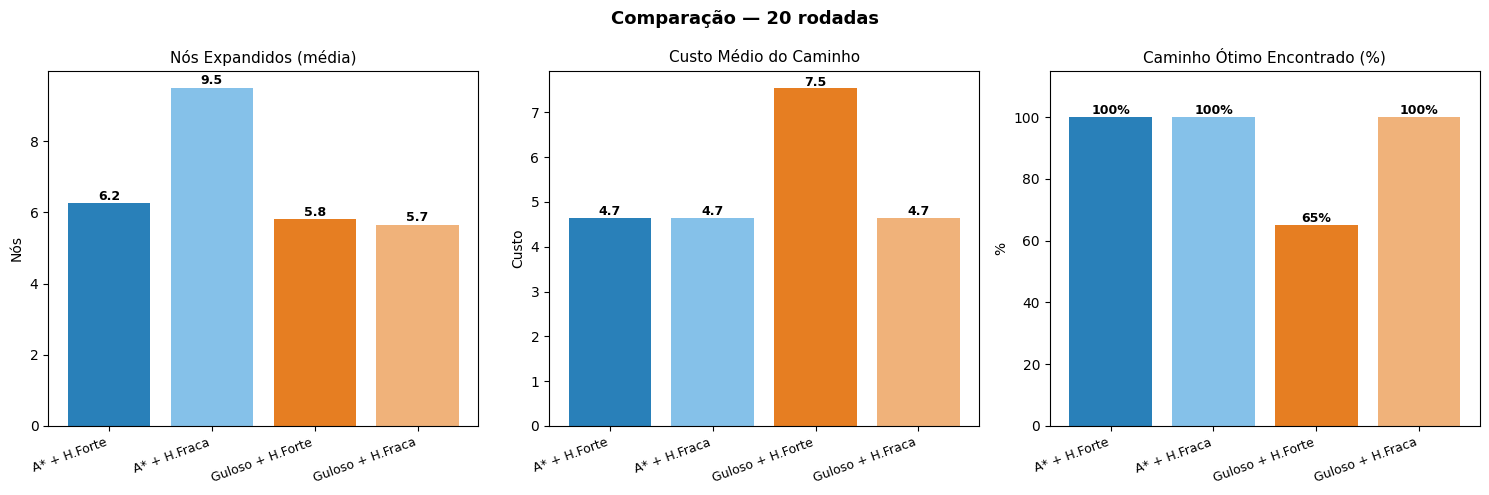

In [42]:
nomes  = [n for n,_,_ in combinacoes]
cores  = ['#2980b9', '#85c1e9', '#e67e22', '#f0b27a']

med_nos   = [np.mean(acumulado[n]['nos'])   for n in nomes]
med_custo = [np.mean(acumulado[n]['custo']) for n in nomes]
pct_otimo = [acumulado[n]['otimo'] / RODADAS * 100 for n in nomes]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Comparação — {RODADAS} rodadas', fontsize=13, fontweight='bold')

x = range(len(nomes))

# Nós expandidos
axes[0].bar(x, med_nos, color=cores)
axes[0].set_title('Nós Expandidos (média)', fontsize=11)
axes[0].set_ylabel('Nós')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nomes, rotation=20, ha='right', fontsize=9)
for i, v in enumerate(med_nos):
    axes[0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Custo médio
axes[1].bar(x, med_custo, color=cores)
axes[1].set_title('Custo Médio do Caminho', fontsize=11)
axes[1].set_ylabel('Custo')
axes[1].set_xticks(x)
axes[1].set_xticklabels(nomes, rotation=20, ha='right', fontsize=9)
for i, v in enumerate(med_custo):
    axes[1].text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# Percentual de ótimos
axes[2].bar(x, pct_otimo, color=cores)
axes[2].set_title('Caminho Ótimo Encontrado (%)', fontsize=11)
axes[2].set_ylabel('%')
axes[2].set_ylim(0, 115)
axes[2].set_xticks(x)
axes[2].set_xticklabels(nomes, rotation=20, ha='right', fontsize=9)
for i, v in enumerate(pct_otimo):
    axes[2].text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Distribuição de Nós por Rodada

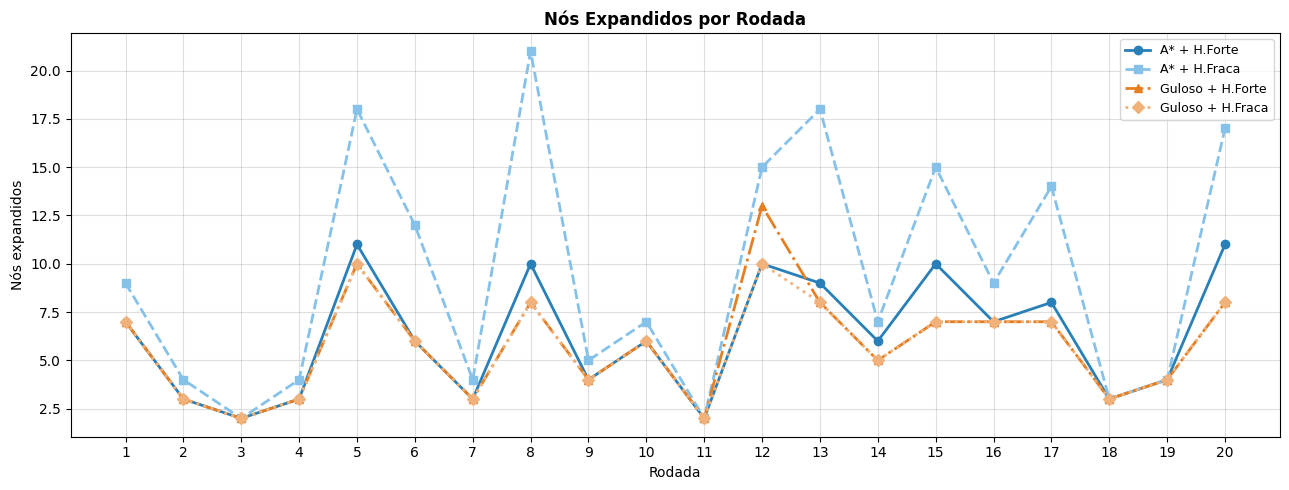

In [43]:
fig, ax = plt.subplots(figsize=(13, 5))

rodadas_x = list(range(1, RODADAS + 1))
estilos = [('-', 'o'), ('--', 's'), ('-.', '^'), (':', 'D')]

for (nome, _, _), cor, (ls, mk) in zip(combinacoes, cores, estilos):
    ax.plot(rodadas_x, acumulado[nome]['nos'], linestyle=ls, marker=mk,
            color=cor, label=nome, linewidth=2, markersize=6)

ax.set_title('Nós Expandidos por Rodada', fontsize=12, fontweight='bold')
ax.set_xlabel('Rodada')
ax.set_ylabel('Nós expandidos')
ax.set_xticks(rodadas_x)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Casos Extremos

In [ ]:
random.seed(SEED)

pior_diff = 0
pior_grade = pior_origem = pior_destino = None
pior_caminho_gf = pior_expansao_gf = None
pior_caminho_af = pior_expansao_af = None
pior_custo_otimo = None

for _ in range(200):
    g, o, d = gerar_tabuleiro()
    c_af, _, custo_af, exp_af = a_estrela(g, o, d, h_forte)
    c_gf, _, custo_gf, exp_gf = guloso(g, o, d, h_forte)
    if custo_gf is not None and custo_af is not None:
        diff = custo_gf - custo_af
        if diff > pior_diff:
            pior_diff = diff
            pior_grade, pior_origem, pior_destino = g, o, d
            pior_caminho_af, pior_expansao_af = c_af, exp_af
            pior_caminho_gf, pior_expansao_gf = c_gf, exp_gf
            pior_custo_otimo = custo_af

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(
    f'Caso Extremo — Guloso erra por {pior_diff} unidades de custo\n'
    f'Origem {pior_origem} → Destino {pior_destino}',
    fontsize=12, fontweight='bold'
)

plotar_busca(pior_grade, pior_origem, pior_destino,
             pior_caminho_af, pior_expansao_af, 'A* + H.Forte', pior_custo_otimo, ax=axes[0])
plotar_busca(pior_grade, pior_origem, pior_destino,
             pior_caminho_gf, pior_expansao_gf, 'Guloso + H.Forte', pior_custo_otimo, ax=axes[1])

fig.legend(handles=LEGENDA_TERRENOS, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

## 10. Conclusão

| Critério | Melhor abordagem |
|---|---|
| Garantia de otimalidade | **A\*** (qualquer heurística admissível) |
| Menor nós expandidos | Guloso + H.Forte |
| Melhor equilíbrio geral | **A\* + H.Forte** |
| Pior caso observado | Guloso + H.Forte (50% de erros) |

**A H.Forte reduz 36% dos nós expandidos no A\*** em relação à H.Fraca, sem perder a otimalidade.  
**O Guloso com H.Forte** é o mais eficiente em nós, mas comete erros significativos ao ignorar o custo acumulado — priorizando a direção geométrica ao invés do custo real do terreno.  
**O Guloso com H.Fraca** acerta 100% dos casos neste tabuleiro, pois a estimativa quase-zero o força a explorar o espaço de forma mais uniforme, comportando-se próximo a uma busca de custo uniforme.